# Чат-бот с саммаризацией сообщений (Chatbot with message summarization)

## Обзор (Review)

Мы рассмотрели, как настраивать схему состояния графа (graph state schema) и редьюсеры (reducers).

Также мы показали несколько способов обрезки (trimming) или фильтрации (filtering) сообщений в состоянии графа (graph state).

## Цели (Goals)

Теперь давайте сделаем шаг вперед!

Вместо простой обрезки (trimming) или фильтрации (filtering) сообщений мы покажем, как использовать LLM (языковые модели) для создания текущей саммаризации (summarization) разговора.

Это позволяет сохранить сжатое представление всего разговора, вместо того чтобы просто удалять его при обрезке (trimming) или фильтрации (filtering).

Мы внедрим эту саммаризацию (summarization) в простого чат-бота.

И оснастим этого чат-бота памятью (memory), что позволит поддерживать длительные диалоги без высоких затрат на токены (token cost) и задержек (latency).

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

In [2]:
import os
api_key = os.getenv("GIGA_API_KEY")

In [3]:
llm = model = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.0,
    profanity_check = False,
    model="GigaChat-Max",
)

In [4]:
from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

Мы определим узел (node) для вызова нашей LLM (языковой модели), который будет включать саммаризацию (summary), если она существует, в промпт (prompt).

In [5]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Определяем логику вызова модели
def call_model(state: State):
    
    # Получаем саммаризацию (summary), если она существует
    summary = state.get("summary", "")

    # Если саммаризация (summary) есть, добавляем её
    if summary:
        
        # Добавляем саммаризацию (summary) в системное сообщение (SystemMessage)
        system_message = f"Саммаризация (summary) предыдущего разговора: {summary}"

        # Добавляем саммаризацию (summary) к новым сообщениям
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    # Вызываем модель
    response = model.invoke(messages)
    return {"messages": response}

Мы определим узел (node) для создания саммаризации (summary).

Обратите внимание, что здесь мы будем использовать `RemoveMessage`, чтобы отфильтровать наше состояние (state) после создания саммаризации (summary).

In [6]:
def summarize_conversation(state: State):
    
    # Сначала получаем существующую саммаризацию (summary), если она есть
    summary = state.get("summary", "")

    # Создаем промпт (prompt) для саммаризации (summarization)
    if summary:
        
        # Саммаризация (summary) уже существует
        summary_message = (
            f"Это саммаризация (summary) текущего разговора: {summary}\n\n"
            "Расширьте саммаризацию (summary), учитывая новые сообщения выше:"
        )
        
    else:
        summary_message = "Создайте саммаризацию (summary) разговора выше:"

    # Добавляем промпт (prompt) к истории сообщений
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Удаляем все сообщения, кроме двух последних
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

Мы добавим условное ребро (conditional edge), чтобы определить, нужно ли создавать саммаризацию (summary) на основе длины разговора.

In [7]:
from langgraph.graph import END

# Определяем, нужно ли завершить разговор или создать саммаризацию (summary)
def should_continue(state: State):
    
    """Возвращает следующий узел (node) для выполнения."""
    
    messages = state["messages"]
    
    # Если сообщений больше шести, создаем саммаризацию (summary) разговора
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Иначе завершаем выполнение
    return END

================================================================================================

## Добавление памяти (Adding memory)

Напомним, что [состояние (state) является временным](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) для одного выполнения графа.

Это ограничивает наши возможности для ведения многоходовых диалогов с перерывами.

Как было показано в конце Модуля 1, мы можем использовать [персистентность (persistence)](https://langchain-ai.github.io/langgraph/how-tos/persistence/), чтобы решить эту проблему!

LangGraph может использовать **чекпоинтер (checkpointer)** для автоматического сохранения состояния графа после каждого шага.

Этот встроенный слой персистентности (persistence) предоставляет нам память (memory), позволяя LangGraph продолжить работу с последнего обновления состояния.

Как мы уже показывали ранее, одним из самых простых в использовании является `MemorySaver` — хранилище типа "ключ-значение" в памяти для состояния графа.

Все, что нам нужно сделать, — это скомпилировать граф с чекпоинтером (checkpointer), и наш граф получит память (memory)!

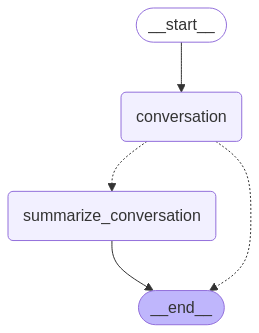

In [8]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Треды (Threads)

Чекпоинтер (checkpointer) сохраняет состояние (state) на каждом шаге как чекпоинт (checkpoint).

Эти сохраненные чекпоинты (checkpoints) могут быть сгруппированы в **тред (thread)** разговора.

Подумайте о Slack как об аналоге: разные каналы ведут разные разговоры.

Треды (threads) похожи на каналы Slack, они захватывают сгруппированные коллекции состояний (например, разговоров).

Ниже мы используем `configurable`, чтобы задать ID треда (thread ID).

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbadf3b379c2ee621adfd1_chatbot-summarization1.png)

In [9]:
# Создаем тред (thread)
config = {"configurable": {"thread_id": "1"}}

# Начинаем разговор
input_message = HumanMessage(content="Привет! Меня зовут Лэнс")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

# Продолжаем разговор
input_message = HumanMessage(content="Как меня зовут?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

# Добавляем новое сообщение
input_message = HumanMessage(content="Мне нравятся 49ers!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Привет, Лэнс! Рад знакомству. Чем могу быть полезен?
================================== Ai Message ==================================

Твое имя – Лэнс.
================================== Ai Message ==================================

Отличный выбор команды! "Сан-Франциско Форти Найнерс" (San Francisco 49ers) — одна из самых успешных команд НФЛ с богатой историей и множеством титулов. Кто твой любимый игрок?


In [10]:
graph.get_state(config).values.get("summary","")

''

In [11]:
input_message = HumanMessage(content="Мне нравится Ник Боса, разве он не самый высокооплачиваемый защитник?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Да, ты прав. Ник Боса действительно является одним из самых высокооплачиваемых защитников в НФЛ. В августе 2023 года он подписал пятилетний контракт на сумму около $170 миллионов, что сделало его самым высокооплачиваемым защитником лиги на тот момент.

Боса — отличный игрок, который уже успел показать себя как один из лучших пас-рашеров в лиге. Его навыки и вклад в игру делают его ценным активом для "Форти Найнерс".


In [12]:
graph.get_state(config).values.get("summary","")

'Лэнс представился и упомянул свою любовь к команде "Сан-Франциско Форти Найнерс". Он также выразил восхищение игроком этой команды Ником Босой, отметив, что тот является одним из самых высокооплачиваемых защитников в НФЛ благодаря своему недавнему контракту на сумму около $170 миллионов.'